In [ ]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
import joblib


In [2]:
#  2. Load Dataset

import pandas as pd

# 2. Load Dataset
df = pd.read_csv('studentbinaryclass.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (125, 9)


,Unnamed: 0,Student_ID,Student_Name,Study_Hours_Per_Day,Attendance_%,Previous_GPA,Assignments_Submitted,Sleep_Hours,Final_Marks
0,0,STU001,Fatima Noor,4.4,90.4,3.85,1.0,6.1,1
1,1,STU002,Ali Hassan,9.6,94.8,3.88,2.0,8.5,1
2,2,STU003,Hamza Sheikh,NaN,65.9,NaN,0.0,4.6,1
3,3,STU004,Zainab Hussain,6.4,55.5,2.43,0.0,NaN,1
4,4,STU005,Zainab Hussain,99.0,NaN,1.54,2.0,NaN,0


In [4]:
# 3. Exploratory Data Analysis (EDA)

print("Data Types:\n", df.dtypes) 
print("\nSummary Statistics:\n", df.describe(include='all'))  
print("\nMissing Values:\n", df.isnull().sum())  
print("\nDuplicate Rows:", df.duplicated().sum())  

Data Types:
 Unnamed: 0                 int64
Student_ID                object
Student_Name              object
Study_Hours_Per_Day      float64
Attendance_%             float64
Previous_GPA             float64
Assignments_Submitted     object
Sleep_Hours               object
Final_Marks                int64
dtype: object

Summary Statistics:
         Unnamed: 0 Student_ID  Student_Name  Study_Hours_Per_Day  \
count   125.000000        125           125           114.000000   
unique         NaN        120            30                  NaN   
top            NaN     STU021  Hamza Sheikh                  NaN   
freq           NaN          2            11                  NaN   
mean     62.000000        NaN           NaN             6.160526   
std      36.228442        NaN           NaN             9.401399   
min       0.000000        NaN           NaN            -3.000000   
25%      31.000000        NaN           NaN             2.800000   
50%      62.000000        NaN           Na

Unique values in Student_ID: ['STU001' 'STU002' 'STU003' 'STU004' 'STU005' 'STU006' 'STU007' 'STU008'
 'STU009' 'STU010' 'STU011' 'STU012' 'STU013' 'STU014' 'STU015' 'STU016'
 'STU017' 'STU018' 'STU019' 'STU020' 'STU021' 'STU022' 'STU023' 'STU024'
 'STU025' 'STU026' 'STU027' 'STU028' 'STU029' 'STU030' 'STU031' 'STU032'
 'STU033' 'STU034' 'STU035' 'STU036' 'STU037' 'STU038' 'STU039' 'STU040'
 'STU041' 'STU042' 'STU043' 'STU044' 'STU045' 'STU046' 'STU047' 'STU048'
 'STU049' 'STU050' 'STU051' 'STU052' 'STU053' 'STU054' 'STU055' 'STU056'
 'STU057' 'STU058' 'STU059' 'STU060' 'STU061' 'STU062' 'STU063' 'STU064'
 'STU065' 'STU066' 'STU067' 'STU068' 'STU069' 'STU070' 'STU071' 'STU072'
 'STU073' 'STU074' 'STU075' 'STU076' 'STU077' 'STU078' 'STU079' 'STU080'
 'STU081' 'STU082' 'STU083' 'STU084' 'STU085' 'STU086' 'STU087' 'STU088'
 'STU089' 'STU090' 'STU091' 'STU092' 'STU093' 'STU094' 'STU095' 'STU096'
 'STU097' 'STU098' 'STU099' 'STU100' 'STU101' 'STU102' 'STU103' 'STU104'
 'STU105' 'STU106' 'ST

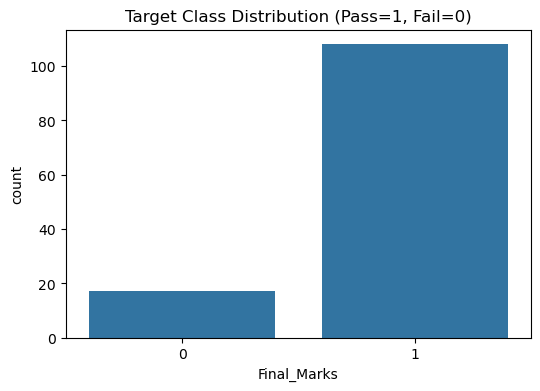

Final_Marks
1    0.864
0    0.136
Name: proportion, dtype: float64


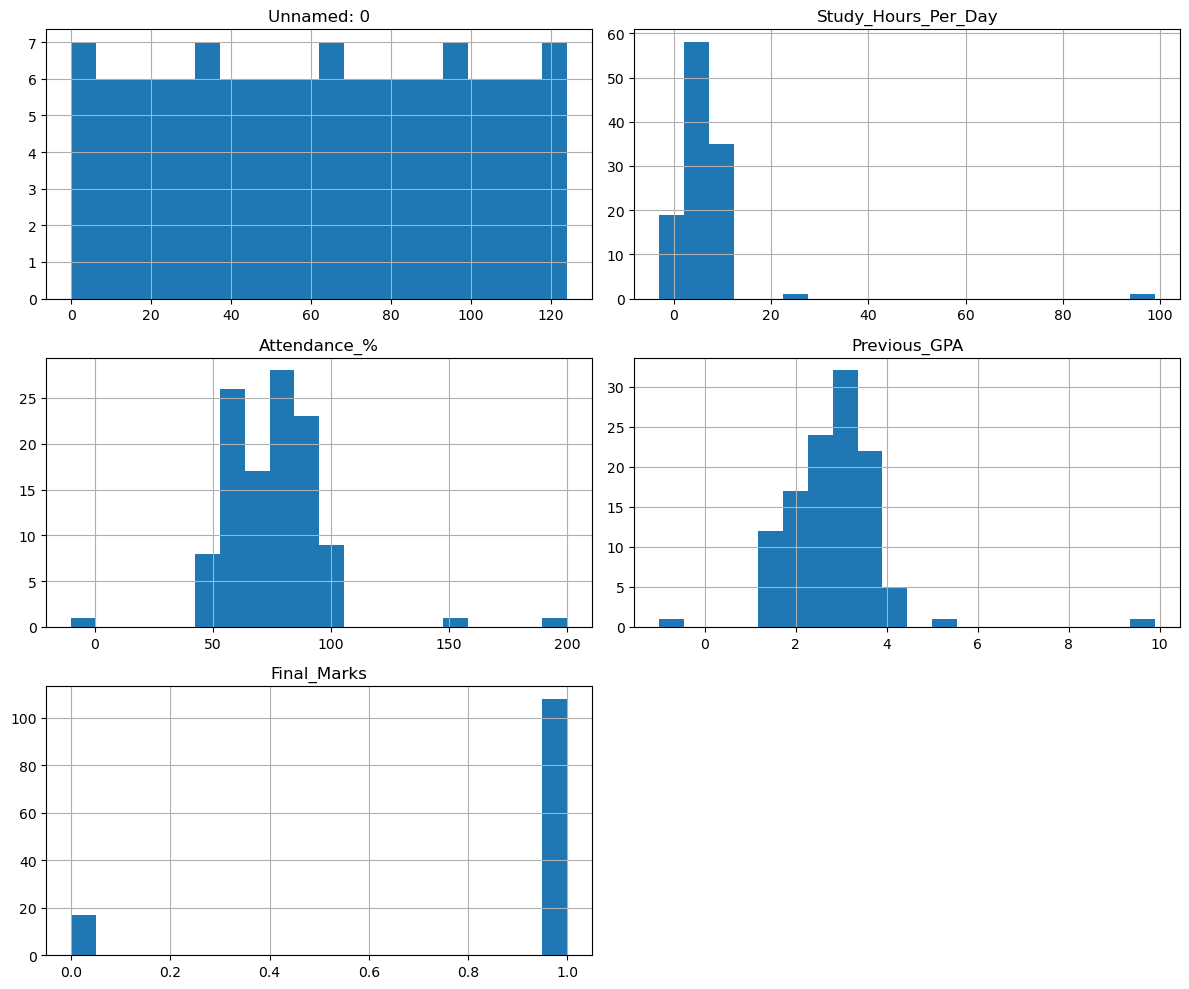

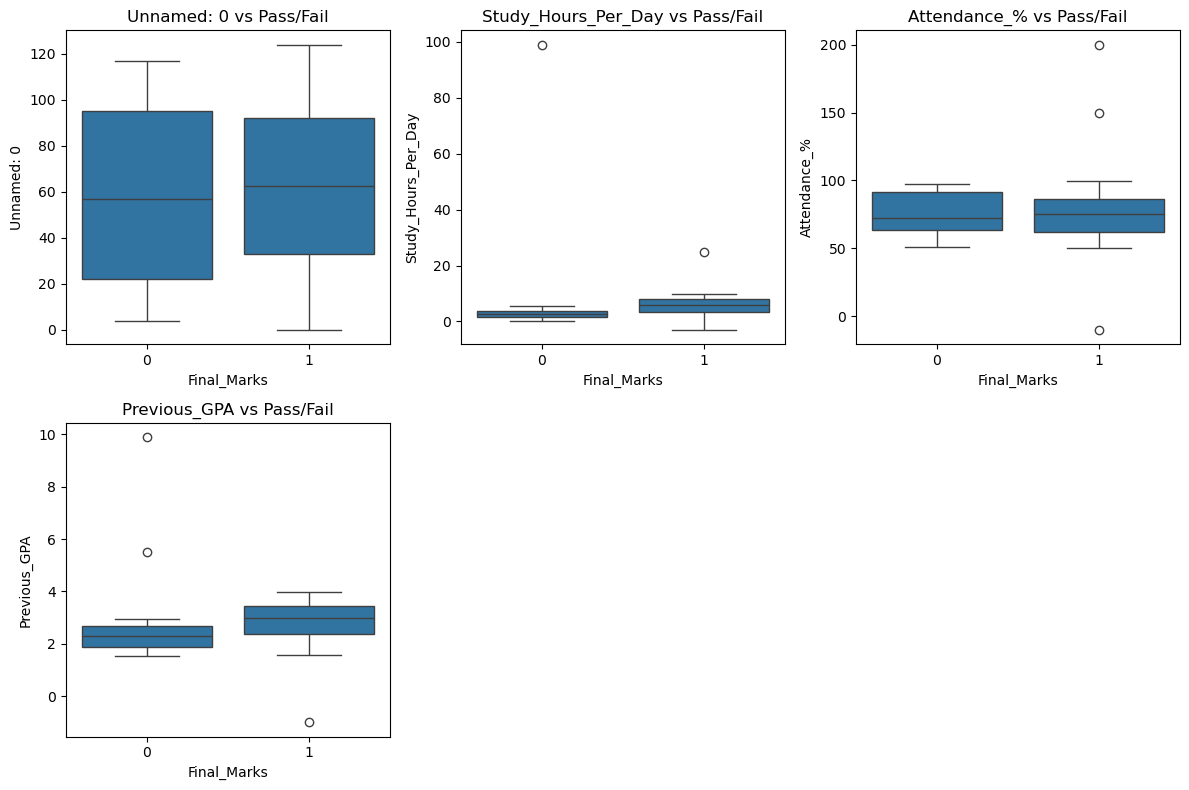

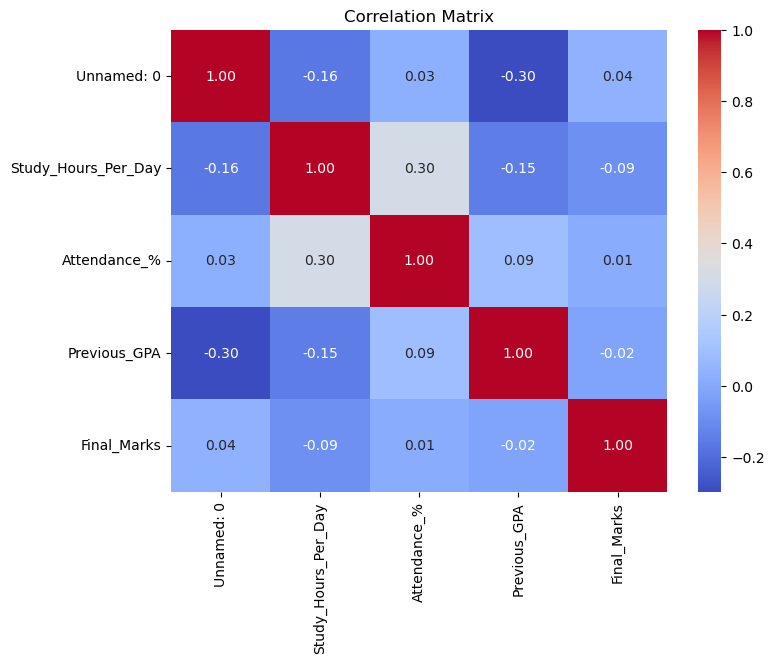

In [10]:
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd  

# Display unique values for categorical columns only
for col in df.select_dtypes(include='object').columns:
    print(f"Unique values in {col}:", df[col].unique()) 

plt.figure(figsize=(6,4))
sns.countplot(x='Final_Marks', data=df)
plt.title('Target Class Distribution (Pass=1, Fail=0)')
plt.show()
print(df['Final_Marks'].value_counts(normalize=True))

# Create histograms for numeric columns only (excluding string/ID columns)
numeric_df = df.select_dtypes(include=[np.number])  # Filter to numeric columns only
numeric_df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
# Get numeric columns excluding the target variable for boxplots
numeric_cols = df.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col != 'Final_Marks']  # Exclude target variable

for i, col in enumerate(feature_cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(x='Final_Marks', y=col, data=df)
    plt.title(f'{col} vs Pass/Fail')
plt.tight_layout()
plt.show()

# Calculate correlation matrix for numeric columns only
plt.figure(figsize=(8,6))
correlation_matrix = numeric_df.corr()  # Only numeric columns for correlation
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [12]:
# Import necessary libraries for data preprocessing
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 4. Data Preprocessing & Feature Engineering

if 'Study_Hours' in df.columns:
    df['Study_Hours'] = pd.to_numeric(df['Study_Hours'], errors='coerce')
    
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].apply(lambda x: np.nan if x < 0 else x)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('Final_Marks')  # Remove target

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

# Create preprocessing pipelines with all required imports now available
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('power_transform', PowerTransformer(method='yeo-johnson'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

Categorical columns: ['Student_ID', 'Student_Name', 'Assignments_Submitted', 'Sleep_Hours']
Numerical columns: ['Unnamed: 0', 'Study_Hours_Per_Day', 'Attendance_%', 'Previous_GPA']


In [14]:
# Import the required function from sklearn
from sklearn.model_selection import train_test_split

X = df.drop('Final_Marks', axis=1)
y = df['Final_Marks']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (100, 8)
Test set size: (25, 8)


In [18]:
# Fixed: Added missing import statement
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, classification_report, 
                           confusion_matrix)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),

}

results = []
best_model = None
best_accuracy = 0

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, 'predict_proba') else None
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
    
    # Save best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline


Logistic Regression Results:
              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.92      1.00      0.96        22

    accuracy                           0.92        25
   macro avg       0.96      0.67      0.73        25
weighted avg       0.93      0.92      0.90        25

Confusion Matrix:
[[ 1  2]
 [ 0 22]]

Random Forest Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.88      1.00      0.94        22

    accuracy                           0.88        25
   macro avg       0.44      0.50      0.47        25
weighted avg       0.77      0.88      0.82        25

Confusion Matrix:
[[ 0  3]
 [ 0 22]]

SVM Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.88      1.00      0.94        22

    accuracy                           0

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\anaconda3\Lib\site-packages\s

Model Performance Comparison:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.92   0.916667     1.0  0.956522 0.878788
      Random Forest      0.88   0.880000     1.0  0.936170 0.590909
                SVM      0.88   0.880000     1.0  0.936170 0.757576


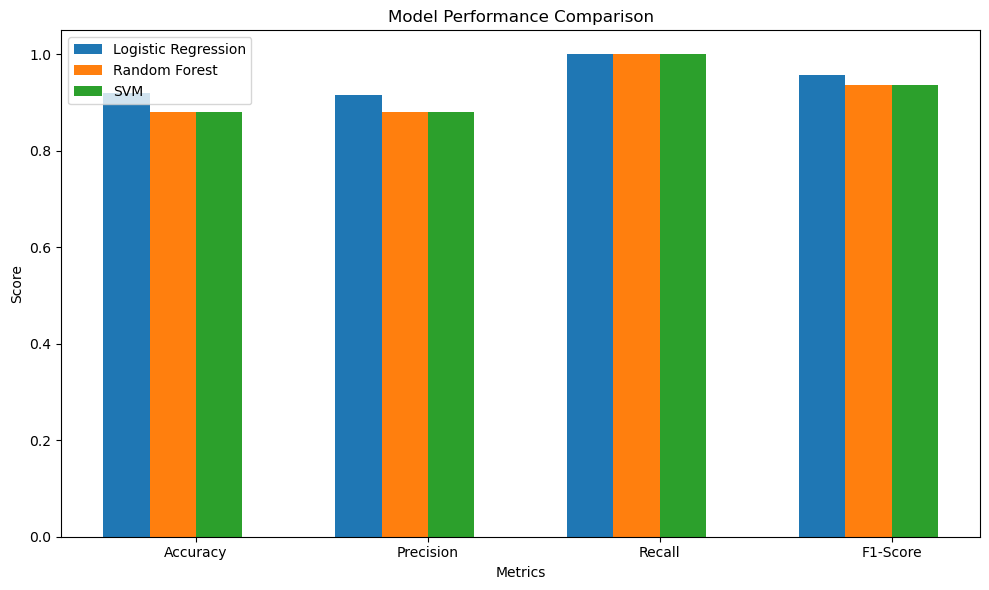

In [20]:
# 7. Model Comparison

results_df = pd.DataFrame(results)
print("Model Performance Comparison:") 
print(results_df.to_string(index=False))

# Plot comparison
plt.figure(figsize=(10,6))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.2

for i, row in results_df.iterrows():
    values = [row[m] for m in metrics]
    plt.bar(x + i*width, values, width, label=row['Model'])

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x + width*1.5, metrics)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# 8. Save Final Model
import joblib

joblib.dump(best_model, 'student_performance_model.pkl')
print(f"Best model saved: {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']} with accuracy: {best_accuracy:.4f}")
print("Model saved as 'student_performance_model.pkl'")

Best model saved: Logistic Regression with accuracy: 0.9200
Model saved as 'student_performance_model.pkl'


In [23]:
# 9. Test Loaded Model (Optional)
loaded_model = joblib.load('student_performance_model.pkl')
sample_pred = loaded_model.predict(X_test[:5])
print("Sample predictions on test data:", sample_pred)


Sample predictions on test data: [1 1 1 1 1]
